In [1]:
# ==============================================================================
# Cell 1: Installation
# ==============================================================================
!pip install -q transformers

In [2]:
# ==============================================================================
# Cell 2: Imports
# ==============================================================================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchvision
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from transformers import SwinForImageClassification

In [3]:
# ==============================================================================
# Cell 3: Reproducibility Seed
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()


In [4]:
# ==============================================================================
# Cell 4: Configuration & Data Loaders
# ==============================================================================
class Config:
    DATA_DIR = '/kaggle/input/datasets/shahjaman/brain-stroke-classification-image-data-v1'  
    TRAIN_DIR = os.path.join(DATA_DIR, 'Train')
    TEST_DIR = os.path.join(DATA_DIR, 'Test')
    EXT_TEST_DIR = os.path.join(DATA_DIR, 'External_test')
    
    IMAGE_SIZE = (224, 224)
    BATCH_SIZE = 32
    NUM_WORKERS = os.cpu_count()
    
    LEARNING_RATE = 0.0001
    WEIGHT_DECAY = 0.2     
    NUM_EPOCHS = 15        
    NUM_CLASSES = 3        
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

train_transform = transforms.Compose([
    transforms.Resize(Config.IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5), 
    transforms.RandomRotation(degrees=15),  
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(Config.IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def get_dataloaders():
    train_dataset = datasets.ImageFolder(Config.TRAIN_DIR, transform=train_transform)
    test_dataset = datasets.ImageFolder(Config.TEST_DIR, transform=test_transform)
    ext_test_dataset = datasets.ImageFolder(Config.EXT_TEST_DIR, transform=test_transform)
    
    class_names = train_dataset.classes
    
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, 
                             num_workers=Config.NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, 
                            num_workers=Config.NUM_WORKERS, pin_memory=True)
    ext_test_loader = DataLoader(ext_test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, 
                            num_workers=Config.NUM_WORKERS, pin_memory=True)
    
    return train_loader, test_loader, ext_test_loader, class_names

train_dataloader, test_dataloader, ext_test_dataloader, class_names = get_dataloaders()
print(f"Loaded Classes: {class_names}")

Loaded Classes: ['Hemorrhage', 'Ischemia', 'Normal']


In [5]:
# ==============================================================================
# Cell 5: Swin Model Initialization
# ==============================================================================
def create_swin_model():
    model = SwinForImageClassification.from_pretrained(
        'microsoft/swin-tiny-patch4-window7-224', 
        num_labels=Config.NUM_CLASSES, 
        ignore_mismatched_sizes=True
    )
    return model.to(Config.DEVICE)

swin_model = create_swin_model()

optimizer = optim.AdamW(swin_model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=Config.NUM_EPOCHS)
loss_fn = nn.CrossEntropyLoss()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/113M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                        
------------------+----------+----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([3, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([3])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [6]:
# ==============================================================================
# Cell 6: Training Execution
# ==============================================================================
def train_model(model, train_loader, test_loader, ext_test_loader, optimizer, loss_fn, scheduler, epochs, device):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": [], "ext_test_acc": []}
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_acc = 0, 0
        for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            y_pred = outputs.logits
            loss = loss_fn(y_pred, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_acc += (y_pred.argmax(dim=1) == y).sum().item() / len(y)
            
        train_loss /= len(train_loader)
        train_acc /= len(train_loader)
        
        model.eval()
        test_loss, test_acc, ext_test_acc = 0, 0, 0
        with torch.inference_mode():
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                y_pred = outputs.logits
                test_loss += loss_fn(y_pred, y).item()
                test_acc += (y_pred.argmax(dim=1) == y).sum().item() / len(y)
                
            for X, y in ext_test_loader:
                X, y = X.to(device), y.to(device)
                outputs = model(X)
                y_pred = outputs.logits
                ext_test_acc += (y_pred.argmax(dim=1) == y).sum().item() / len(y)
                
        test_loss /= len(test_loader)
        test_acc /= len(test_loader)
        ext_test_acc /= len(ext_test_loader)
        
        scheduler.step()
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f} | Ext Test Acc: {ext_test_acc:.4f}")
        
        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        results["ext_test_acc"].append(ext_test_acc)
        
    return results

results = train_model(swin_model, train_dataloader, test_dataloader, ext_test_dataloader, optimizer, loss_fn, scheduler, Config.NUM_EPOCHS, Config.DEVICE)

save_path = f'/kaggle/working/BrainStroke_Swin_model_{Config.NUM_EPOCHS}epochs.pth'
torch.save(swin_model.state_dict(), save_path)
print(f"Model successfully saved to: {save_path}")

Epoch 1/15: 100%|██████████| 375/375 [02:36<00:00,  2.40it/s]


Train Loss: 0.6457 | Train Acc: 0.7121 | Test Acc: 0.7855 | Ext Test Acc: 0.7567


Epoch 2/15: 100%|██████████| 375/375 [02:41<00:00,  2.32it/s]


Train Loss: 0.4239 | Train Acc: 0.8253 | Test Acc: 0.8117 | Ext Test Acc: 0.8149


Epoch 3/15: 100%|██████████| 375/375 [02:42<00:00,  2.31it/s]


...

Train Loss: 0.0403 | Train Acc: 0.9845 | Test Acc: 0.8855 | Ext Test Acc: 0.9228


Epoch 14/15: 100%|██████████| 375/375 [02:42<00:00,  2.31it/s]


Train Loss: 0.0339 | Train Acc: 0.9869 | Test Acc: 0.8823 | Ext Test Acc: 0.9261


Epoch 15/15: 100%|██████████| 375/375 [02:41<00:00,  2.32it/s]


Train Loss: 0.0314 | Train Acc: 0.9880 | Test Acc: 0.8866 | Ext Test Acc: 0.9245
Model successfully saved to: /kaggle/working/BrainStroke_Swin_model_15epochs.pth


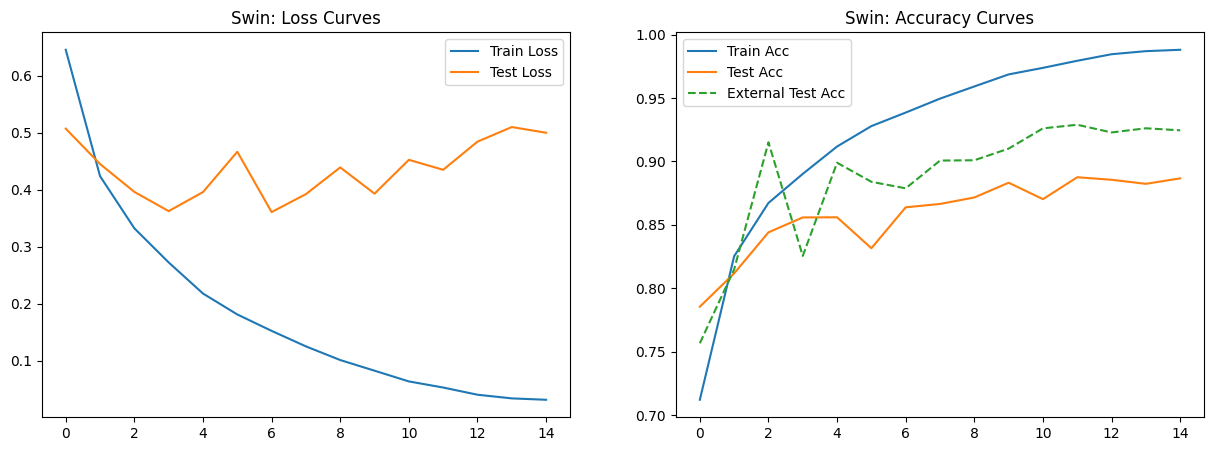

In [7]:
# ==============================================================================
# Cell 7: Performance Plotting
# ==============================================================================
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 1)
plt.plot(results["train_loss"], label="Train Loss")
plt.plot(results["test_loss"], label="Test Loss")
plt.title("Swin: Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(results["train_acc"], label="Train Acc")
plt.plot(results["test_acc"], label="Test Acc")
plt.plot(results["ext_test_acc"], label="External Test Acc", linestyle='--')
plt.title("Swin: Accuracy Curves")
plt.legend()
plt.show()


[INFO] All Swin artifacts will be saved to: swin_evaluation_results/

[INFO] Saving trained Swin model...
[SUCCESS] Model successfully saved to folder: swin_evaluation_results/BrainStroke_Swin_model_15epochs.pth

[INFO] Plotting Swin Training History...


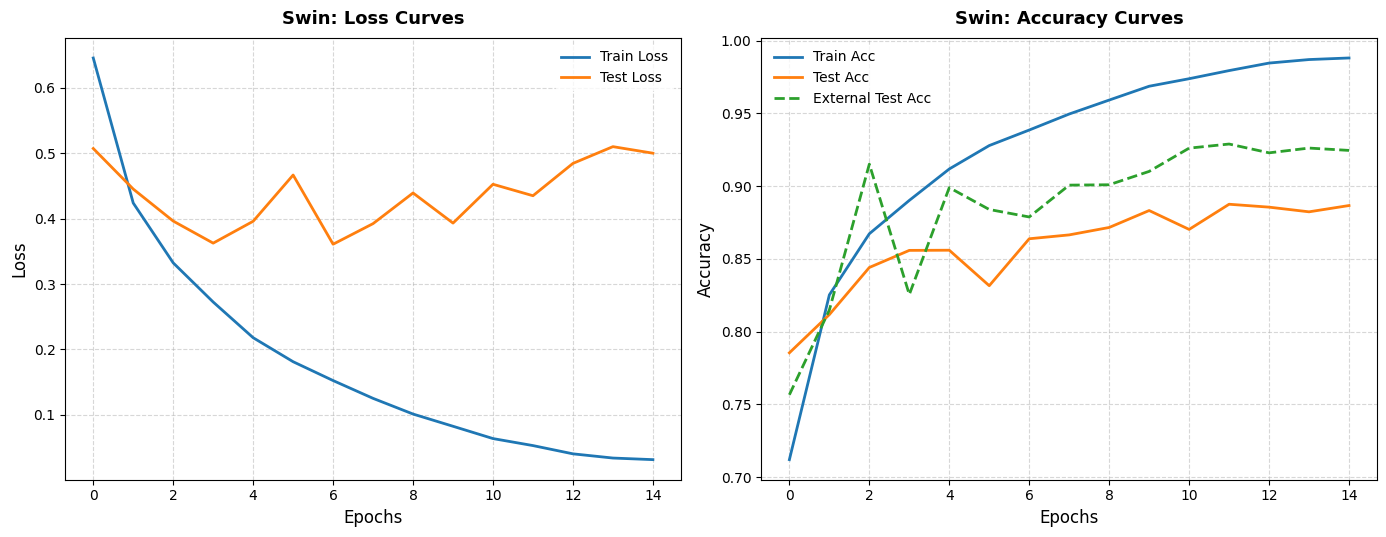


Evaluating Metrics on: Standard Test Set

--- Classification Report ---
              precision    recall  f1-score   support

  Hemorrhage       0.92      0.86      0.89      1000
    Ischemia       0.98      0.86      0.92      1000
      Normal       0.80      0.94      0.86      1000

    accuracy                           0.89      3000
   macro avg       0.90      0.89      0.89      3000
weighted avg       0.90      0.89      0.89      3000



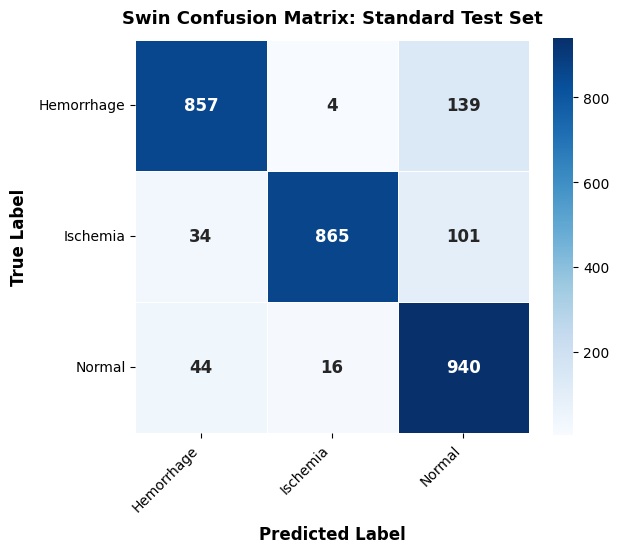


Evaluating Metrics on: External Test Set

--- Classification Report ---
              precision    recall  f1-score   support

  Hemorrhage       0.89      0.93      0.91       250
    Ischemia       0.99      0.94      0.96       157
      Normal       0.92      0.91      0.92       232

    accuracy                           0.92       639
   macro avg       0.93      0.93      0.93       639
weighted avg       0.93      0.92      0.93       639



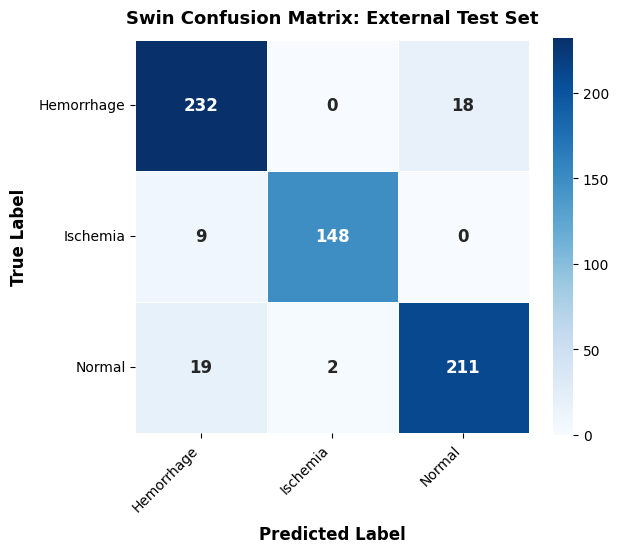


Generating ROC Curve for: Standard Test Set...


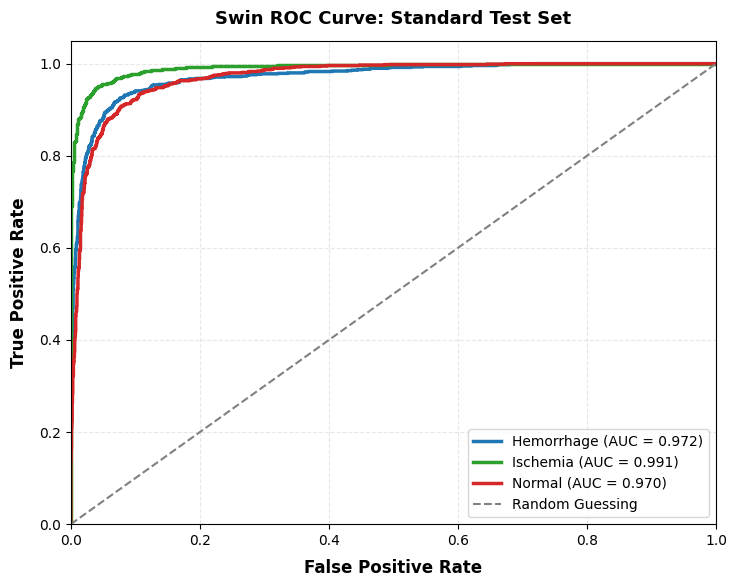


Generating ROC Curve for: External Test Set...


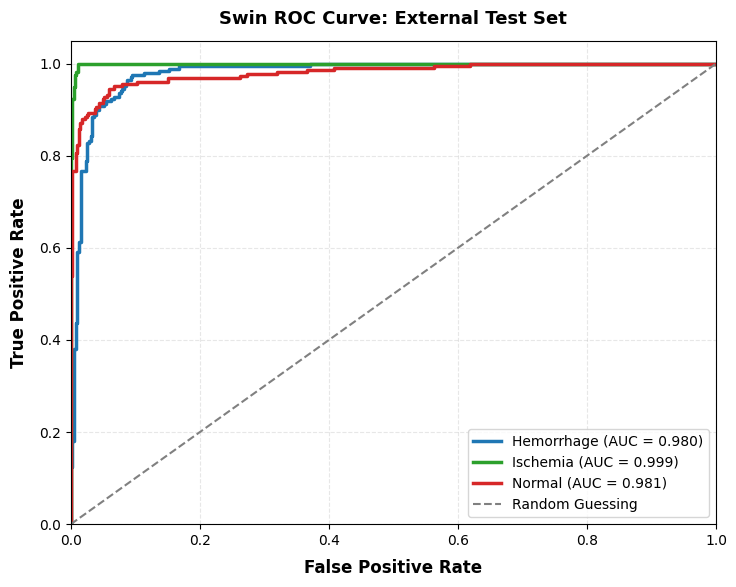


Testing Single Image Prediction on: /kaggle/input/datasets/shahjaman/brain-stroke-classification-image-data-v1/External_test/Ischemia/I_0028.jpg


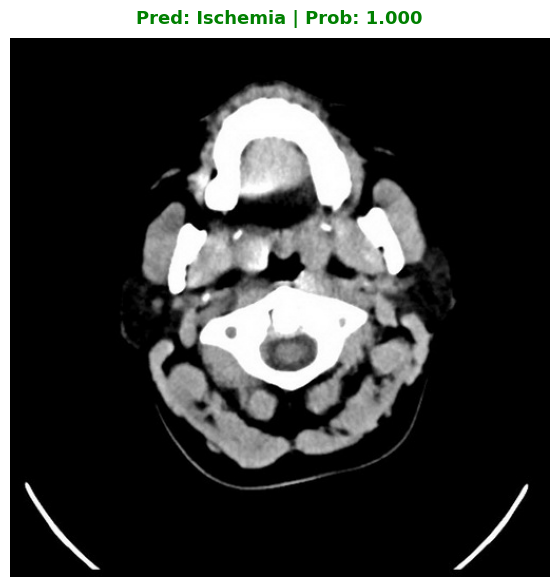


[INFO] Zipping all Swin results and model weights...
[SUCCESS] All artifacts packed into 'swin_evaluation_results.zip'

--- CLICK THE LINK BELOW TO DOWNLOAD YOUR ZIP FILE ---


/kaggle/working/swin_evaluation_results.zip

In [9]:
# ==============================================================================
# Cell 8: Detailed Evaluation, Reports, Visualizations and Archiving
# ==============================================================================
import os
import shutil
import numpy as np
import torch
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from IPython.display import FileLink

OUTPUT_DIR = "swin_evaluation_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 14
})

print(f"[INFO] All Swin artifacts will be saved to: {OUTPUT_DIR}/")

print("\n[INFO] Saving trained Swin model...")
folder_save_path = os.path.join(OUTPUT_DIR, f"BrainStroke_Swin_model_{Config.NUM_EPOCHS}epochs.pth")
torch.save(swin_model.state_dict(), folder_save_path)
print(f"[SUCCESS] Model successfully saved to folder: {folder_save_path}")

print("\n[INFO] Plotting Swin Training History...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].plot(results["train_loss"], label="Train Loss", color='#1f77b4', linewidth=2)
axes[0].plot(results["test_loss"], label="Test Loss", color='#ff7f0e', linewidth=2)
axes[0].set_title("Swin: Loss Curves", fontweight='bold', pad=10)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend(frameon=True, facecolor='white', edgecolor='none')

axes[1].plot(results["train_acc"], label="Train Acc", color='#1f77b4', linewidth=2)
axes[1].plot(results["test_acc"], label="Test Acc", color='#ff7f0e', linewidth=2)
if "ext_test_acc" in results:
    axes[1].plot(results["ext_test_acc"], label="External Test Acc", color='#2ca02c', linestyle='--', linewidth=2)
axes[1].set_title("Swin: Accuracy Curves", fontweight='bold', pad=10)
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "swin_training_history_curves.png"), dpi=300, bbox_inches='tight')
plt.show()

def evaluate_and_plot_metrics(model, dataloader, class_names, device, dataset_name="Test Set"):
    filename_suffix = dataset_name.lower().replace(" ", "_")
    print(f"\n=========================================")
    print(f"Evaluating Metrics on: {dataset_name}")
    print(f"=========================================\n")
    
    model.eval()
    y_true, y_pred = [], []
    with torch.inference_mode():
        for X, y in dataloader:
            X = X.to(device)
            outputs = model(X)
            predictions = torch.argmax(outputs.logits, dim=1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(predictions.cpu().numpy())
            
    report_text = classification_report(y_true, y_pred, target_names=class_names)
    print("--- Classification Report ---")
    print(report_text)
    
    report_path = os.path.join(OUTPUT_DIR, f"swin_classification_report_{filename_suffix}.txt")
    with open(report_path, "w") as f:
        f.write(f"Swin Classification Report - {dataset_name}\n")
        f.write("="*40 + "\n")
        f.write(report_text)
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6.5, 5.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                square=True, cbar=True, linewidths=.5,
                annot_kws={"size": 12, "weight": "bold"})
    
    plt.title(f'Swin Confusion Matrix: {dataset_name}', fontweight='bold', pad=12)
    plt.ylabel('True Label', fontweight='bold', labelpad=8)
    plt.xlabel('Predicted Label', fontweight='bold', labelpad=8)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    plt.savefig(os.path.join(OUTPUT_DIR, f"swin_confusion_matrix_{filename_suffix}.png"), dpi=300, bbox_inches='tight')
    plt.show()

evaluate_and_plot_metrics(swin_model, test_dataloader, class_names, Config.DEVICE, dataset_name="Standard Test Set")
evaluate_and_plot_metrics(swin_model, ext_test_dataloader, class_names, Config.DEVICE, dataset_name="External Test Set")

def plot_multiclass_roc(model, dataloader, class_names, device, dataset_name="Test Set"):
    filename_suffix = dataset_name.lower().replace(" ", "_")
    print(f"\nGenerating ROC Curve for: {dataset_name}...")
    
    model.eval()
    y_true, y_probs = [], []
    
    with torch.inference_mode():
        for X, y in dataloader:
            X = X.to(device)
            outputs = model(X)
            probabilities = torch.softmax(outputs.logits, dim=1)
            y_true.extend(y.cpu().numpy())
            y_probs.extend(probabilities.cpu().numpy())
            
    y_true = np.array(y_true)
    y_probs = np.array(y_probs)
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))
    
    plt.figure(figsize=(7.5, 6))
    colors = ['#1f77b4', '#2ca02c', '#d62728'] 
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=colors[i % len(colors)], lw=2.5, 
                 label=f'{class_names[i]} (AUC = {roc_auc:.3f})')
                 
    plt.plot([0, 1], [0, 1], color='grey', lw=1.5, linestyle='--', label='Random Guessing')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontweight='bold', labelpad=8)
    plt.ylabel('True Positive Rate', fontweight='bold', labelpad=8)
    plt.title(f'Swin ROC Curve: {dataset_name}', fontsize=13, fontweight='bold', pad=12)
    plt.legend(loc="lower right", frameon=True, facecolor='white')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    plt.savefig(os.path.join(OUTPUT_DIR, f"swin_roc_curve_{filename_suffix}.png"), dpi=300, bbox_inches='tight')
    plt.show()

plot_multiclass_roc(swin_model, test_dataloader, class_names, Config.DEVICE, dataset_name="Standard Test Set")
plot_multiclass_roc(swin_model, ext_test_dataloader, class_names, Config.DEVICE, dataset_name="External Test Set")

def pred_and_plot_image(model, image_path, class_names, transform=None, device='cuda' if torch.cuda.is_available() else 'cpu'):
    print(f"\nTesting Single Image Prediction on: {image_path}")
    human_image = Image.open(image_path).convert('RGB')
    
    target_image = torchvision.io.read_image(
        str(image_path), mode=torchvision.io.ImageReadMode.RGB
    ).type(torch.float32) / 255.0
    
    if transform:
        target_image = transform(target_image)
    
    model.to(device)
    model.eval()
    with torch.inference_mode():
        target_image = target_image.unsqueeze(dim=0).to(device)
        outputs = model(target_image)
        target_image_pred_probs = torch.softmax(outputs.logits, dim=1)
        target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(human_image)
    
    prob_val = target_image_pred_probs.max().cpu().item()
    pred_class = class_names[target_image_pred_label.cpu().item()]
    title = f"Pred: {pred_class} | Prob: {prob_val:.3f}"
    
    title_color = 'green' if prob_val > 0.80 else 'orange'
    plt.title(title, fontsize=13, fontweight='bold', color=title_color, pad=10)
    plt.axis(False)
    plt.tight_layout()
    
    plt.savefig(os.path.join(OUTPUT_DIR, "swin_single_image_prediction.png"), dpi=300, bbox_inches='tight')
    plt.show()

CLASS_NAMES = ['Hemorrhage', 'Ischemia', 'Normal'] 
TEST_IMAGE_PATH = '/kaggle/input/datasets/shahjaman/brain-stroke-classification-image-data-v1/External_test/Ischemia/I_0028.jpg'

custom_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

pred_and_plot_image(model=swin_model, image_path=TEST_IMAGE_PATH, class_names=CLASS_NAMES, transform=custom_transform, device=Config.DEVICE)

print("\n[INFO] Zipping all Swin results and model weights...")
shutil.make_archive(OUTPUT_DIR, 'zip', OUTPUT_DIR)
print(f"[SUCCESS] All artifacts packed into '{OUTPUT_DIR}.zip'")

print("\n--- CLICK THE LINK BELOW TO DOWNLOAD YOUR ZIP FILE ---")
display(FileLink(f'{OUTPUT_DIR}.zip'))